# 03 — Forecasting y Proyección de Costos

**Objetivo:** Generar proyecciones de costos futuros para Equipo 1 y Equipo 2 con intervalos de confianza.

---

In [89]:
# =====================================================
# LIBRERÍAS Y CONFIGURACIÓN DEL PROYECTO
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

sys.path.append("../src")

from forecasting import (
    forecast_with_prophet,
    forecast_with_arima,
    plot_forecast
)

PROCESSED_PATH = Path("../data/processed")
REPORTS_PATH = Path("../reports")

REPORTS_PATH.mkdir(exist_ok=True)

print("✅ Librerías cargadas")

✅ Librerías cargadas


## 1. Carga de Series Temporales

In [90]:
# =====================================================
# CARGA DE SERIES TEMPORALES
# =====================================================

df = pd.read_csv(PROCESSED_PATH / "historico_equipos_limpio.csv")

# Conversión de fechas
df["Date"] = pd.to_datetime(df["Date"])

# Orden cronológico
df = df.sort_values("Date").reset_index(drop=True)

print("✅ Dataset cargado correctamente")
print(f"📊 Filas: {df.shape[0]:,}")
print(f"📈 Variables: {df.shape[1]}")
print(
    f"📅 Periodo: "
    f"{df['Date'].min().date()} → "
    f"{df['Date'].max().date()}"
)

# Series objetivo
series_equipos = df[
    ["Date", "Price_Equipo1", "Price_Equipo2"]
].copy()

print("\n🔎 Valores nulos:")
print(series_equipos.isnull().sum())

series_equipos.head()

✅ Dataset cargado correctamente
📊 Filas: 3,530
📈 Variables: 6
📅 Periodo: 2010-01-04 → 2023-08-31

🔎 Valores nulos:
Date             0
Price_Equipo1    0
Price_Equipo2    0
dtype: int64


,Date,Price_Equipo1,Price_Equipo2
0,2010-01-04,434.73,931.73
1,2010-01-05,449.97,968.56
2,2010-01-06,444.48,960.51
3,2010-01-07,440.90,960.14
4,2010-01-08,448.82,949.55


## 2. Análisis de Estacionariedad

In [91]:
# =====================================================
# ANÁLISIS DE ESTACIONARIEDAD
# =====================================================
#
# El test de Dickey-Fuller Aumentado (ADF) permite evaluar
# si una serie temporal es estacionaria.
#
# Este análisis ayuda a seleccionar modelos apropiados para
# forecasting y comprender la presencia de tendencias de largo plazo.
#
# Dado que las series presentan tendencia y posibles cambios
# estructurales observados durante el EDA, se evalúan modelos
# capaces de manejar este comportamiento, incluyendo Prophet
# y ARIMA con diferenciación.
# =====================================================

from statsmodels.tsa.stattools import adfuller

def adf_test(series, nombre):
    result = adfuller(series.dropna())

    print(f"\nSerie: {nombre}")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")

    if result[1] < 0.05:
        conclusion = "La serie parece estacionaria."
    else:
        conclusion = "La serie NO parece estacionaria."

    print(f"Conclusión: {conclusion}")

    return {
        "serie": nombre,
        "adf_statistic": result[0],
        "p_value": result[1],
        "estacionaria": result[1] < 0.05
    }

adf_equipo1 = adf_test(
    df["Price_Equipo1"],
    "Equipo 1"
)

adf_equipo2 = adf_test(
    df["Price_Equipo2"],
    "Equipo 2"
)


Serie: Equipo 1
ADF Statistic: -2.3903
p-value: 0.1445
Conclusión: La serie NO parece estacionaria.

Serie: Equipo 2
ADF Statistic: -1.9064
p-value: 0.3290
Conclusión: La serie NO parece estacionaria.


In [92]:
# =====================================================
# VALIDACIÓN TEMPORAL
# =====================================================
# Este conjunto de validación se utiliza para comparar
# el desempeño de los modelos sobre datos recientes.

fecha_corte = "2023-01-01"

train_df = df[df["Date"] < fecha_corte].copy()
test_df = df[df["Date"] >= fecha_corte].copy()

print("Train:", len(train_df))
print("Test :", len(test_df))

print(
    train_df["Date"].min().date(),
    "→",
    train_df["Date"].max().date()
)

print(
    test_df["Date"].min().date(),
    "→",
    test_df["Date"].max().date()
)

Train: 3358
Test : 172
2010-01-04 → 2022-12-30
2023-01-03 → 2023-08-31


## 

In [93]:
# =====================================================
# VALIDACIÓN DE HORIZONTES DE PREDICCIÓN
# =====================================================
#
# Objetivo:
# Evaluar cómo se degrada el desempeño del modelo
# a medida que aumenta el horizonte de forecast.
#
# Este análisis permite seleccionar un horizonte
# de predicción técnicamente justificable para la
# planeación financiera.
# =====================================================

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error
)
import numpy as np
import pandas as pd

# --------------------------
# BACKTESTING
# --------------------------

cutoff_date = "2022-08-31"

train = df[df["Date"] <= cutoff_date]
test = df[df["Date"] > cutoff_date]

train_series = train.set_index("Date")["Price_Equipo1"]
train_series = train_series.asfreq("B")
train_series = train_series.interpolate()

# --------------------------
# ENTRENAMIENTO
# --------------------------

model = ARIMA(train_series, order=(1,1,1))
model_fit = model.fit()

# --------------------------
# EVALUACIÓN DE HORIZONTES
# --------------------------

resultados = []

for horizonte in [30, 90, 180]:

    forecast = model_fit.forecast(steps=horizonte)

    real = test["Price_Equipo1"].iloc[:horizonte].values

    mae = mean_absolute_error(real, forecast)

    rmse = np.sqrt(
        np.mean((real - forecast.values) ** 2)
    )

    mape = (
        mean_absolute_percentage_error(
            real,
            forecast
        ) * 100
    )

    resultados.append({
        "Horizonte": horizonte,
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "MAPE (%)": round(mape, 2)
    })

pd.DataFrame(resultados)

,Horizonte,MAE,RMSE,MAPE (%)
0,30,9.87,11.63,2.08
1,90,16.36,19.69,3.53
2,180,32.88,40.36,6.49


## 3. Forecasting — Equipo 1

### 3.3 Validación Temporal — ARIMA Equipo 1


In [94]:
# =====================================================
# VALIDACIÓN TEMPORAL — ARIMA EQUIPO 1
# =====================================================
#
# Se entrena un modelo ARIMA utilizando únicamente
# el conjunto de entrenamiento y posteriormente se
# generan predicciones para el período de validación.
#
# A continuación se muestra una muestra de las
# predicciones generadas junto con sus intervalos
# de confianza al 80%.
# =====================================================

forecast_arima_equipo1 = forecast_with_arima(
    train_df["Price_Equipo1"],
    periods=len(test_df)
)

print(
    f"Predicciones generadas: "
    f"{len(forecast_arima_equipo1)}"
)

forecast_arima_equipo1.reset_index(
    drop=True
).head()

Predicciones generadas: 172


,forecast,lower_80,upper_80
0,491.050221,469.081829,513.018614
1,491.418759,466.971298,515.866219
2,491.767654,464.932431,518.602877
3,492.097954,462.946952,521.248957
4,492.410651,461.003019,523.818282


In [95]:
# =====================================================
# MÉTRICAS ARIMA - EQUIPO 1
# =====================================================
#
# Se comparan las predicciones generadas por ARIMA
# contra los valores reales observados en el conjunto
# de validación temporal.
#
# Se calculan RMSE, MAE y MAPE para evaluar la precisión
# del modelo y determinar su capacidad predictiva sobre
# datos no utilizados durante el entrenamiento.
# =====================================================

y_real = test_df["Price_Equipo1"].values

y_pred_arima = (
    forecast_arima_equipo1["forecast"]
    .values
)

rmse_arima_1 = np.sqrt(
    mean_squared_error(
        y_real,
        y_pred_arima
    )
)

mae_arima_1 = mean_absolute_error(
    y_real,
    y_pred_arima
)

mape_arima_1 = (
    mean_absolute_percentage_error(
        y_real,
        y_pred_arima
    ) * 100
)

if mape_arima_1 < 10:
    calidad = "Excelente"
elif mape_arima_1 < 20:
    calidad = "Buena"
elif mape_arima_1 < 30:
    calidad = "Aceptable"
else:
    calidad = "Baja"

print("ARIMA - Equipo 1")
print(f"RMSE : {rmse_arima_1:.2f}")
print(f"MAE  : {mae_arima_1:.2f}")
print(f"MAPE : {mape_arima_1:.2f}%")
print(f"Calidad del modelo: {calidad}")

ARIMA - Equipo 1
RMSE : 36.84
MAE  : 33.04
MAPE : 6.94%
Calidad del modelo: Excelente


### 3.4 Validación Temporal — ARIMA Equipo 2


In [96]:
# =====================================================
# VALIDACIÓN TEMPORAL — ARIMA EQUIPO 2
# =====================================================
#
# Se entrena un modelo ARIMA utilizando únicamente
# el conjunto de entrenamiento y posteriormente se
# generan predicciones para el período de validación.
#
# A continuación se muestra una muestra de las
# predicciones generadas junto con sus intervalos
# de confianza al 80%.
# =====================================================

forecast_arima_equipo2 = forecast_with_arima(
    train_df["Price_Equipo2"],
    periods=len(test_df)
)

print(
    f"Predicciones generadas: "
    f"{len(forecast_arima_equipo2)}"
)

forecast_arima_equipo2.reset_index(
    drop=True
).head()

Predicciones generadas: 172


,forecast,lower_80,upper_80
0,1008.663071,965.358945,1051.967197
1,1008.663071,960.505867,1056.820276
2,1008.663071,956.098964,1061.227178
3,1008.663071,952.033977,1065.292166
4,1008.663071,948.241855,1069.084287


In [97]:
# =====================================================
# MÉTRICAS ARIMA - EQUIPO 2
# =====================================================
#
# Se comparan las predicciones generadas por ARIMA
# contra los valores reales observados en el conjunto
# de validación temporal.
#
# Se calculan RMSE, MAE y MAPE para evaluar la precisión
# del modelo y determinar su capacidad predictiva sobre
# datos no utilizados durante el entrenamiento.
# =====================================================

y_real = test_df["Price_Equipo2"].values

y_pred_arima = (
    forecast_arima_equipo2["forecast"]
    .values
)

rmse_arima_2 = np.sqrt(
    mean_squared_error(
        y_real,
        y_pred_arima
    )
)

mae_arima_2 = mean_absolute_error(
    y_real,
    y_pred_arima
)

mape_arima_2 = (
    mean_absolute_percentage_error(
        y_real,
        y_pred_arima
    ) * 100
)

if mape_arima_2 < 10:
    calidad = "Excelente"
elif mape_arima_2 < 20:
    calidad = "Buena"
elif mape_arima_2 < 30:
    calidad = "Aceptable"
else:
    calidad = "Baja"

print("ARIMA - Equipo 2")
print(f"RMSE : {rmse_arima_2:.2f}")
print(f"MAE  : {mae_arima_2:.2f}")
print(f"MAPE : {mape_arima_2:.2f}%")
print(f"Calidad del modelo: {calidad}")

ARIMA - Equipo 2
RMSE : 63.06
MAE  : 52.74
MAPE : 5.47%
Calidad del modelo: Excelente


In [98]:
# =====================================================
# RESUMEN DE VALIDACIÓN DEL MODELO ARIMA
# =====================================================
#
# Se presenta un resumen consolidado de las métricas
# obtenidas durante la validación temporal para ambos
# equipos.
#
# Los resultados permiten verificar la capacidad
# predictiva del modelo antes de generar los
# pronósticos futuros.
# =====================================================

resumen_arima = pd.DataFrame({
    "Equipo": [
        "Equipo 1",
        "Equipo 2"
    ],
    "RMSE": [
        round(rmse_arima_1, 2),
        round(rmse_arima_2, 2)
    ],
    "MAE": [
        round(mae_arima_1, 2),
        round(mae_arima_2, 2)
    ],
    "MAPE (%)": [
        round(mape_arima_1, 2),
        round(mape_arima_2, 2)
    ]
})

display(resumen_arima)

print(
    """
Conclusión:

El modelo ARIMA presentó un desempeño excelente
en ambos equipos.

Equipo 1:
MAPE = 6.94%

Equipo 2:
MAPE = 5.47%

Dado que ambos errores son inferiores al 10%,
el modelo se considera adecuado para la
generación de pronósticos futuros.
"""
)

,Equipo,RMSE,MAE,MAPE (%)
0,Equipo 1,36.84,33.04,6.94
1,Equipo 2,63.06,52.74,5.47



Conclusión:

El modelo ARIMA presentó un desempeño excelente
en ambos equipos.

Equipo 1:
MAPE = 6.94%

Equipo 2:
MAPE = 5.47%

Dado que ambos errores son inferiores al 10%,
el modelo se considera adecuado para la
generación de pronósticos futuros.



In [99]:
# =====================================================
# CONFIGURACIÓN DEL HORIZONTE DE PRONÓSTICO
# =====================================================
#
# Se define un horizonte de seis meses para la
# proyección de costos operativos futuros.
# =====================================================

HORIZONTE_DIAS = 180

print(
    f"Horizonte de pronóstico: "
    f"{HORIZONTE_DIAS} días"
)

Horizonte de pronóstico: 180 días


## 4. Forecasting Final con ARIMA

In [100]:
# =====================================================
# FORECAST FINAL - ARIMA EQUIPO 1
# =====================================================
#
# Se genera un pronóstico de 180 días utilizando
# la totalidad de los datos históricos disponibles.
# =====================================================

forecast_final_equipo1 = forecast_with_arima(
    df["Price_Equipo1"],
    periods=HORIZONTE_DIAS
)

print(
    f"Predicciones generadas: "
    f"{len(forecast_final_equipo1)}"
)

forecast_final_equipo1.head()

Predicciones generadas: 180


,forecast,lower_80,upper_80
3530,457.117564,435.143753,479.091374
3531,457.053792,432.576756,481.530829
3532,456.993360,430.114312,483.872408
3533,456.936091,427.734301,486.137881
3534,456.881820,425.421985,488.341656


In [101]:
# =====================================================
# FORECAST FINAL - ARIMA EQUIPO 2
# =====================================================
#
# Se genera un pronóstico de 180 días utilizando
# la totalidad de los datos históricos disponibles.
# =====================================================

forecast_final_equipo2 = forecast_with_arima(
    df["Price_Equipo2"],
    periods=HORIZONTE_DIAS
)

print(
    f"Predicciones generadas: "
    f"{len(forecast_final_equipo2)}"
)

forecast_final_equipo2.head()

Predicciones generadas: 180


,forecast,lower_80,upper_80
3530,941.422231,898.042416,984.802046
3531,941.422231,893.179261,989.665202
3532,941.422231,888.763328,994.081134
3533,941.422231,884.690089,998.154373
3534,941.422231,880.890324,1001.954138


In [102]:
# =====================================================
# FECHAS FUTURAS DEL FORECAST
# =====================================================

fechas_futuras = pd.date_range(
    start=df["Date"].max() + pd.Timedelta(days=1),
    periods=HORIZONTE_DIAS,
    freq="D"
)

forecast_final_equipo1["Fecha"] = fechas_futuras
forecast_final_equipo2["Fecha"] = fechas_futuras

forecast_final_equipo1.head()

,forecast,lower_80,upper_80,Fecha
3530,457.117564,435.143753,479.091374,2023-09-01
3531,457.053792,432.576756,481.530829,2023-09-02
3532,456.993360,430.114312,483.872408,2023-09-03
3533,456.936091,427.734301,486.137881,2023-09-04
3534,456.881820,425.421985,488.341656,2023-09-05


### 3.6 Comparación visual de modelos

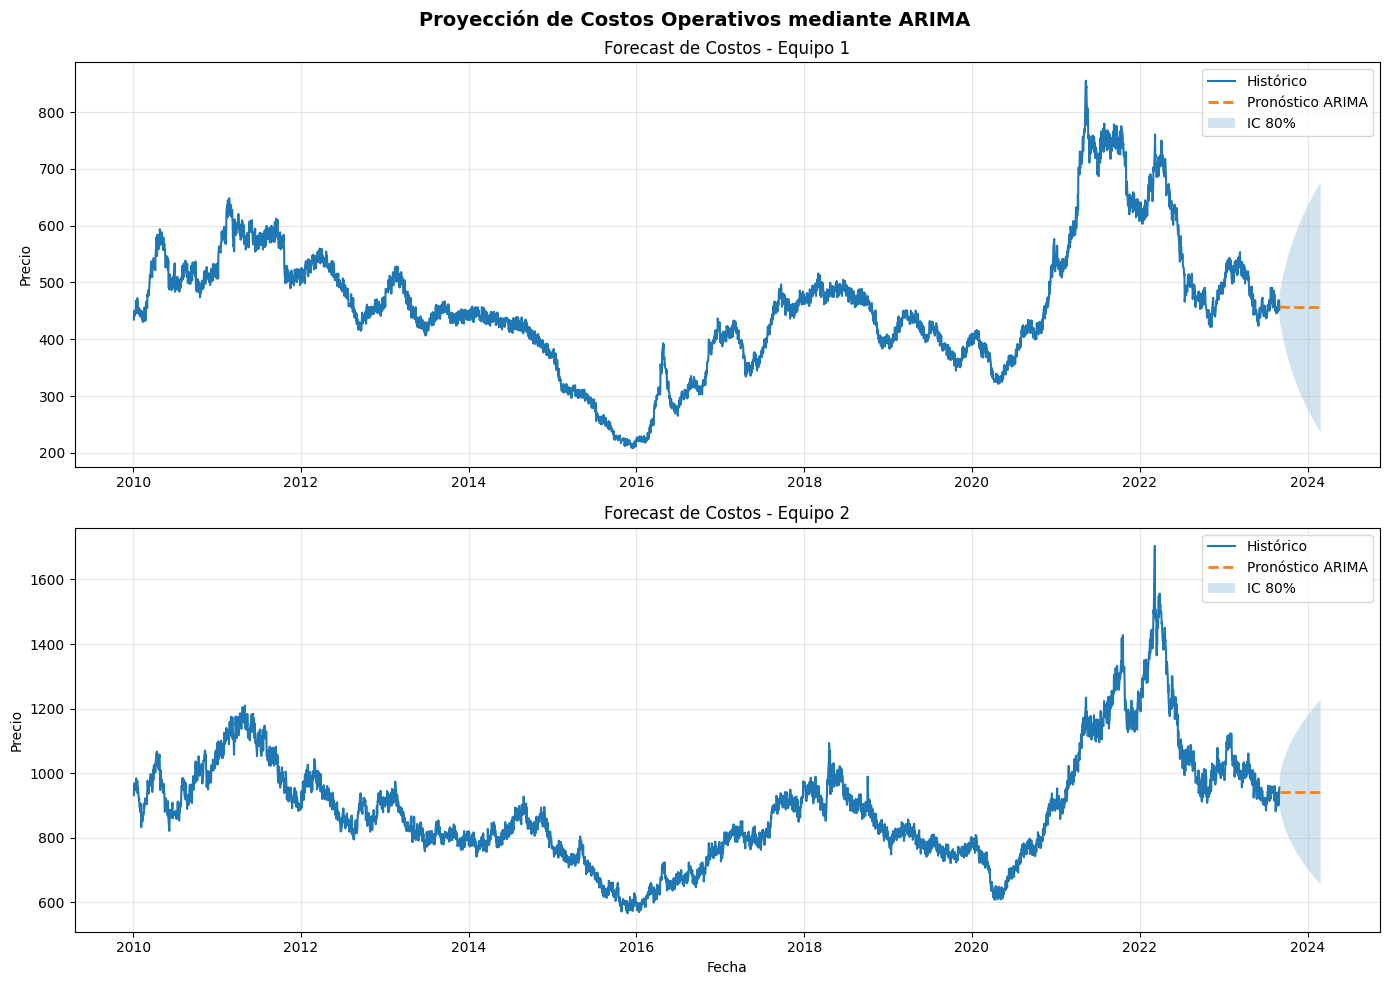

In [103]:
# =====================================================
# VISUALIZACIÓN DE FORECASTS FINALES CON ARIMA
# =====================================================
#
# Se compara la evolución histórica de los costos
# operativos con las proyecciones generadas mediante
# ARIMA para los próximos 180 días.
#
# También se muestran los intervalos de confianza
# al 80%, representando la incertidumbre asociada
# a cada pronóstico.
# =====================================================

fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 10)
)

# =====================================================
# EQUIPO 1
# =====================================================

axes[0].plot(
    df["Date"],
    df["Price_Equipo1"],
    label="Histórico",
    linewidth=1.5
)

axes[0].plot(
    forecast_final_equipo1["Fecha"],
    forecast_final_equipo1["forecast"],
    linestyle="--",
    linewidth=2,
    label="Pronóstico ARIMA"
)

axes[0].fill_between(
    forecast_final_equipo1["Fecha"],
    forecast_final_equipo1["lower_80"],
    forecast_final_equipo1["upper_80"],
    alpha=0.2,
    label="IC 80%"
)

axes[0].set_title(
    "Forecast de Costos - Equipo 1"
)

axes[0].set_ylabel("Precio")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# =====================================================
# EQUIPO 2
# =====================================================

axes[1].plot(
    df["Date"],
    df["Price_Equipo2"],
    label="Histórico",
    linewidth=1.5
)

axes[1].plot(
    forecast_final_equipo2["Fecha"],
    forecast_final_equipo2["forecast"],
    linestyle="--",
    linewidth=2,
    label="Pronóstico ARIMA"
)

axes[1].fill_between(
    forecast_final_equipo2["Fecha"],
    forecast_final_equipo2["lower_80"],
    forecast_final_equipo2["upper_80"],
    alpha=0.2,
    label="IC 80%"
)

axes[1].set_title(
    "Forecast de Costos - Equipo 2"
)

axes[1].set_ylabel("Precio")
axes[1].set_xlabel("Fecha")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(
    "Proyección de Costos Operativos mediante ARIMA",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    REPORTS_PATH /
    "fig_forecast_arima_final.png",
    dpi=120,
    bbox_inches="tight"
)

plt.show()

## 6. Tablas de Proyección de Costos

In [104]:
# =====================================================
# TABLA DE PROYECCIONES - EQUIPO 1
# =====================================================
#
# Se presentan las primeras proyecciones generadas
# por ARIMA para los próximos 180 días junto con sus
# intervalos de confianza al 80%.
# =====================================================

tabla_equipo1 = forecast_final_equipo1[
    ["Fecha", "forecast", "lower_80", "upper_80"]
].copy()

tabla_equipo1.columns = [
    "Fecha",
    "Pronostico",
    "Limite_Inferior",
    "Limite_Superior"
]

tabla_equipo1["Margen_Error"] = (
    tabla_equipo1["Limite_Superior"]
    - tabla_equipo1["Limite_Inferior"]
)

print("Primeras proyecciones - Equipo 1")

display(
    tabla_equipo1.head(10)
)

Primeras proyecciones - Equipo 1


,Fecha,Pronostico,Limite_Inferior,Limite_Superior,Margen_Error
3530,2023-09-01,457.117564,435.143753,479.091374,43.947621
3531,2023-09-02,457.053792,432.576756,481.530829,48.954073
3532,2023-09-03,456.993360,430.114312,483.872408,53.758097
3533,2023-09-04,456.936091,427.734301,486.137881,58.403580
3534,2023-09-05,456.881820,425.421985,488.341656,62.919670
3535,2023-09-06,456.830391,423.167095,490.493687,67.326592
3536,2023-09-07,456.781654,420.962219,492.601089,71.638870
3537,2023-09-08,456.735468,418.801851,494.669086,75.867235
3538,2023-09-09,456.691701,416.681795,496.701606,80.019811
3539,2023-09-10,456.650225,414.598785,498.701664,84.102879


In [105]:
# =====================================================
# TABLA DE PROYECCIONES - EQUIPO 2
# =====================================================
#
# Se presentan las primeras proyecciones generadas
# por ARIMA para los próximos 180 días junto con sus
# intervalos de confianza al 80%.
# =====================================================

tabla_equipo2 = forecast_final_equipo2[
    ["Fecha", "forecast", "lower_80", "upper_80"]
].copy()

tabla_equipo2.columns = [
    "Fecha",
    "Pronostico",
    "Limite_Inferior",
    "Limite_Superior"
]

tabla_equipo2["Margen_Error"] = (
    tabla_equipo2["Limite_Superior"]
    - tabla_equipo2["Limite_Inferior"]
)

print("Primeras proyecciones - Equipo 2")

display(
    tabla_equipo2.head(10)
)

Primeras proyecciones - Equipo 2


,Fecha,Pronostico,Limite_Inferior,Limite_Superior,Margen_Error
3530,2023-09-01,941.422231,898.042416,984.802046,86.759630
3531,2023-09-02,941.422231,893.179261,989.665202,96.485941
3532,2023-09-03,941.422231,888.763328,994.081134,105.317806
3533,2023-09-04,941.422231,884.690089,998.154373,113.464284
3534,2023-09-05,941.422231,880.890324,1001.954138,121.063814
3535,2023-09-06,941.422231,877.315386,1005.529077,128.213691
3536,2023-09-07,941.422231,873.929539,1008.914923,134.985384
3537,2023-09-08,941.422231,870.705618,1012.138844,141.433226
3538,2023-09-09,941.422231,867.622399,1015.222063,147.599664
3539,2023-09-10,941.422231,864.662925,1018.181537,153.518612


In [106]:
# =====================================================
# RESUMEN EJECUTIVO DE PROYECCIONES
# =====================================================
#
# Se resume el comportamiento esperado de los costos
# operativos durante el horizonte de proyección de
# 180 días utilizando el modelo ARIMA seleccionado.
# =====================================================
# =====================================================
resumen_forecast = pd.DataFrame({
    "Equipo": [
        "Equipo 1",
        "Equipo 2"
    ],
    "Precio_Actual": [
        df["Price_Equipo1"].iloc[-1],
        df["Price_Equipo2"].iloc[-1]
    ],
    "Precio_Promedio_Proyectado": [
        tabla_equipo1["Pronostico"].mean(),
        tabla_equipo2["Pronostico"].mean()
    ],
    "Min_Proyectado": [
        tabla_equipo1["Pronostico"].min(),
        tabla_equipo2["Pronostico"].min()
    ],
    "Max_Proyectado": [
        tabla_equipo1["Pronostico"].max(),
        tabla_equipo2["Pronostico"].max()
    ]
})

# Variación esperada respecto al precio actual
resumen_forecast["Variacion_%"] = (
    (
        resumen_forecast["Precio_Promedio_Proyectado"]
        - resumen_forecast["Precio_Actual"]
    )
    / resumen_forecast["Precio_Actual"]
) * 100

resumen_forecast = resumen_forecast.round(2)

display(resumen_forecast)
print(
    """
Interpretación:

• Equipo 1:
  Se proyecta una variación promedio de +0.95%,
  indicando estabilidad con una ligera tendencia
  al incremento de costos.

• Equipo 2:
  Se proyecta una variación promedio de -1.46%,
  indicando estabilidad con una ligera reducción
  respecto al último valor observado.

En ambos casos las variaciones proyectadas son
moderadas, por lo que no se identifican cambios
abruptos en el comportamiento esperado de los costos.
"""
)


,Equipo,Precio_Actual,Precio_Promedio_Proyectado,Min_Proyectado,Max_Proyectado,Variacion_%
0,Equipo 1,451.73,456.03,455.90,457.12,0.95
1,Equipo 2,955.35,941.42,941.42,941.42,-1.46



Interpretación:

• Equipo 1:
  Se proyecta una variación promedio de +0.95%,
  indicando estabilidad con una ligera tendencia
  al incremento de costos.

• Equipo 2:
  Se proyecta una variación promedio de -1.46%,
  indicando estabilidad con una ligera reducción
  respecto al último valor observado.

En ambos casos las variaciones proyectadas son
moderadas, por lo que no se identifican cambios
abruptos en el comportamiento esperado de los costos.



In [107]:
# =====================================================
# RESUMEN EJECUTIVO
# =====================================================
#
# Síntesis de los principales hallazgos obtenidos
# durante el análisis exploratorio, modelado
# predictivo y forecasting.
# =====================================================

resumen_ejecutivo = pd.DataFrame({
    "Hallazgo": [
        "Variable más influyente Equipo 1",
        "Variables relevantes Equipo 2",
        "Mejor modelo predictivo",
        "Mejor modelo forecasting"
    ],
    "Resultado": [
        "Price_Y",
        "Price_X, Price_Y y Price_Z",
        "Regresión Lineal",
        "ARIMA"
    ]
})

display(resumen_ejecutivo)

,Hallazgo,Resultado
0,Variable más influyente Equipo 1,Price_Y
1,Variables relevantes Equipo 2,"Price_X, Price_Y y Price_Z"
2,Mejor modelo predictivo,Regresión Lineal
3,Mejor modelo forecasting,ARIMA


### Interpretación del Resumen Ejecutivo

Las proyecciones generadas mediante el modelo ARIMA muestran un comportamiento relativamente estable para ambos equipos durante el horizonte de pronóstico de 180 días.

Para el **Equipo 1**, el precio promedio proyectado es de **456.03**, frente a un precio actual de **451.73**, lo que representa una variación estimada de **0.95%**. Este resultado sugiere una estabilidad general de los costos, acompañada de un leve incremento esperado que no representa un cambio significativo respecto al nivel actual.

Para el **Equipo 2**, el precio promedio proyectado es de **941.42**, comparado con un precio actual de **955.35**, lo que equivale a una variación estimada de **-1.46%**. Esta proyección indica una ligera reducción en los costos esperados, aunque la magnitud del cambio es moderada y no evidencia una tendencia descendente pronunciada.

Los intervalos de confianza obtenidos muestran que la incertidumbre aumenta gradualmente a medida que se extiende el horizonte temporal, comportamiento característico de los modelos de series temporales. Por esta razón, las proyecciones deben interpretarse como rangos probables de comportamiento futuro y no como valores puntuales exactos.

En conjunto, los resultados sugieren que los costos operativos de ambos equipos tenderían a mantenerse cercanos a los niveles observados al final del período histórico analizado, sin evidencias de cambios abruptos en el corto y mediano plazo.



In [108]:
# =====================================================
# EXPORTACIÓN DE PROYECCIONES
# =====================================================

tabla_equipo1.to_csv(
    PROCESSED_PATH / "forecast_equipo1.csv",
    index=False
)

tabla_equipo2.to_csv(
    PROCESSED_PATH / "forecast_equipo2.csv",
    index=False
)

resumen_forecast.to_csv(
    PROCESSED_PATH / "resumen_forecasts.csv",
    index=False
)

print("Forecasts exportados correctamente.")

Forecasts exportados correctamente.


## 7. Conclusiones del Forecasting

### 7.1 Interpretación de las proyecciones

Las proyecciones generadas mediante el modelo ARIMA muestran un comportamiento relativamente estable para ambos equipos durante el horizonte de pronóstico de 180 días.

Para el **Equipo 1**, el precio promedio proyectado es de **456.03**, frente a un precio actual de **451.73**, lo que representa una variación estimada de **0.95%**. Este resultado sugiere una estabilidad general de los costos, acompañada de un leve incremento que no representa un cambio significativo respecto al nivel actual.

Para el **Equipo 2**, el precio promedio proyectado es de **941.42**, comparado con un precio actual de **955.35**, lo que equivale a una variación estimada de **-1.46%**. Esta proyección indica una ligera reducción en los costos esperados, aunque la magnitud del cambio es moderada y no evidencia una tendencia descendente pronunciada.

Los intervalos de confianza permiten cuantificar la incertidumbre asociada a las proyecciones y muestran que esta aumenta gradualmente a medida que se extiende el horizonte temporal. Por esta razón, los pronósticos deben interpretarse como rangos probables de comportamiento futuro y no como valores puntuales exactos.

En conjunto, los resultados sugieren que los costos operativos de ambos equipos tenderían a mantenerse cercanos a los niveles observados al final del período histórico analizado, sin evidencias de cambios abruptos en el corto y mediano plazo.

### 7.2 Limitaciones

Las proyecciones obtenidas se fundamentan exclusivamente en los patrones históricos observados entre 2010 y 2023. En consecuencia, el modelo asume que las dinámicas que han gobernado el comportamiento de los costos en el pasado continuarán siendo similares durante el horizonte de pronóstico.

Factores externos no representados en los datos históricos, como cambios regulatorios, fluctuaciones extraordinarias en los precios de materias primas, eventos macroeconómicos o modificaciones en los procesos productivos, podrían alterar significativamente la evolución futura de los costos.

Por esta razón, las proyecciones deben interpretarse como escenarios probabilísticos que apoyan la toma de decisiones y no como estimaciones exactas del comportamiento futuro.

### 7.3 Trabajo futuro

Como líneas de mejora se recomienda explorar modelos adicionales de series temporales, tales como SARIMA, así como enfoques basados en Machine Learning para forecasting, incluyendo Gradient Boosting y modelos híbridos que combinen información histórica con variables externas relevantes.

Los resultados obtenidos en el Notebook 02 evidenciaron una relación significativa entre los precios de las materias primas y los costos de los equipos. En futuras iteraciones del proyecto, una estrategia prometedora consistiría en proyectar primero el comportamiento de dichas materias primas y posteriormente utilizar los modelos predictivos desarrollados para estimar los costos operativos de los equipos.

Asimismo, podría incorporarse información económica y de mercado adicional para construir modelos multivariados que permitan capturar factores externos y mejorar la precisión de las proyecciones de largo plazo.


